# Лекция 2. Постановка задачи RL, оценочные функции и уравнение Беллмана

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IlyaChichkanov/Reinforcement-learning/blob/main/02-environments/lecture/lecture.ipynb)

На прошлой лекции мы познакомились с RL на примерах: озеро, эпизоды, «сыграть и усреднить», метод Cross-Entropy. Сегодня разберёмся, **какую задачу мы на самом деле решаем** и как её решать не перебором, а вычислением. Изложение следует главе [«Обучение с подкреплением»](https://education.yandex.ru/handbook/ml/article/obuchenie-s-podkrepleniem) Учебника по машинному обучению ШАД (Яндекс): оттуда взяты ход рассуждений и примеры — тортики, велосипед, Колобок и лотерея. Все формулы мы будем сразу проверять числами на нашем озере.

**Три вопроса лекции** (они же — план):

1. **Как формально записать задачу?** Среда, стратегия, награда, цель — на языке математики (MDP).
2. **Какая стратегия лучшая и как её узнать?** Если бы кто-то дал нам «оценки» — сколько награды можно набрать после каждого действия, — стратегия получалась бы даром. Такие оценки называются $Q^*$, и они удовлетворяют **уравнению Беллмана**.
3. **Откуда взять оценки?** Если мы знаем, как устроена среда, — решить уравнение. Если не знаем — учиться на пробах и ошибках: это **Q-learning**, первый настоящий алгоритм RL, который умеет учиться с каждого шага.

**Что было в лекции 1 → что сегодня**

| Лекция 1 (интуиция) | Лекция 2 (математика) |
|---|---|
| среда — «то, что отвечает на действия» | MDP: состояния, действия, функция переходов $p(s' \mid s, a)$, награда $r$ |
| «сыграть много раз и усреднить» | цель — средняя суммарная награда $\mathbb E\,\sum_t \gamma^t r_t$ по траекториям |
| ценность клетки — «средний return отсюда» | оценочные функции $Q^*$, $V^\pi$, $Q^\pi$ и уравнения Беллмана, которые их связывают |
| Cross-Entropy: искать стратегию перебором эпизодов | вычислить стратегию из уравнения; Q-learning: то же по одному переходу за раз |

**План и хронометраж (одна пара, 90 минут)**

| | Раздел | Минут |
|---|---|---|
| 1 | Обучение методом проб и ошибок | 6 |
| 2 | Постановка задачи: MDP, стратегия, цель | 16 |
| 3 | Примеры MDP (📖 дома) | 4 |
| 4 | Окей, и как такое решать? Оптимальная Q-функция | 12 |
| 5 | Уравнение оптимальности Беллмана | 14 |
| 6 | А если стратегия задана? $V^\pi$, $Q^\pi$ | 12 |
| 7 | А где же метод проб и ошибок? Q-learning | 16 |
| 8 | Что дальше и итоги | 10 |

В лекции семь коротких демо (все на CPU за секунды) и одно в резерве. Служебный код для картинок вынесен в файлы `lake_mdp.py` и `lake_plots.py` рядом с ноутбуком — их читать не нужно. Пометки: **📖 дома** — для самостоятельного чтения, **⏱ если есть время** — резерв.

In [1]:
# Если ноутбук открыт в Google Colab: ставим недостающие пакеты и скачиваем служебные файлы лекции.
# Локально (после uv sync, файлы лежат рядом с ноутбуком) ячейка ничего не делает.
import importlib.util, pathlib, subprocess, sys, urllib.request
if importlib.util.find_spec("gymnasium") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gymnasium[toy-text]"], check=True)
for name in ["lake_mdp.py", "lake_plots.py"]:
    if not pathlib.Path(name).exists():
        urllib.request.urlretrieve("https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/02-environments/lecture/" + name, name)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from lake_mdp import *      # GAMMA, run_session, estimate_values, mdp_matrices, solve_q_star, greedy_policy, success_rate
from lake_plots import *    # draw_transitions, plot_q, draw_backup, plot_values, draw_policy, plot_q_updates

lake = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)   # скользкое озеро из лекции 1
desc = lake_desc(lake)
P, R = mdp_matrices(lake)                                            # модель среды: P[s, a, s'] и ожидаемая награда R[s, a]
n_states, n_actions = R.shape
Q_star = solve_q_star(P, R)                                          # «ответ» для раздела 4; как он получается — раздел 5

## 1. Обучение методом проб и ошибок

До сих пор — и в классическом ML, и в мини-семинаре по PyTorch — опыт, на котором учится алгоритм, был задан обучающей выборкой. Человек учится иначе. Чтобы научиться кататься на велосипеде, печь тортики или играть в теннис, нам не нужны датасеты с примерами «что делать в каждый момент»: мы пробуем, ошибаемся и как-то улучшаем своё поведение по результатам. Это обучение **методом проб и ошибок** (trial and error).

В обучении с подкреплением мы хотим построить алгоритм, который учится именно так. Вместо обучающей выборки он **взаимодействует со средой**, а в роли «разметки» выступает **награда** — число, которое выдаётся после каждого шага и показывает, насколько хорошо идут дела. Печёте тортики — за каждый тортик $+1$; учитесь ездить на велосипеде — за каждое падение $-1$. У награды три свойства, из-за которых RL — отдельная область, а не частный случай supervised learning:

* награда **не подсказывает, как** решать задачу и что вообще нужно делать;
* награда может быть **отложенной** (нашли в пустыне сокровища, но тортики получите, только когда выберетесь) или **разреженной** (почти всегда $+0$);
* и всё же награда — это **сигнал** «хорошо / плохо», которого нет, например, в обучении без учителя.

Что мы умеем после лекции 1: измерить стратегию, сыграв ей много эпизодов (Монте-Карло), и улучшить её, повторяя действия из лучших эпизодов (Cross-Entropy). Чего не хватает: Cross-Entropy смотрит на **целые эпизоды** — эпизод хороший или плохой, и всё. Если агент сделал 99 правильных шагов и один раз оступился, эпизод уходит в мусор вместе с 99 правильными шагами. Чтобы учиться **с каждого шага**, нужно понимать, как устроена задача внутри. Для этого её придётся аккуратно записать.

## 2. Постановка задачи

### 2.1 MDP: среда на языке математики

Задача обучения с подкреплением задаётся **марковским процессом принятия решений** (Markov Decision Process, MDP) — четвёркой $(\mathcal S, \mathcal A, p, r)$:

* $\mathcal S$ — **пространство состояний**: множество состояний, в которых может находиться среда. На озере — 16 клеток.
* $\mathcal A$ — **пространство действий**: из чего агент выбирает на каждом шаге. На озере — четыре направления $\leftarrow \downarrow \rightarrow \uparrow$.
* $p(s' \mid s, a)$ — **функция переходов**: как меняется среда после того, как в состоянии $s$ выбрано действие $a$. В общем случае она случайна, поэтому это распределение: с какой вероятностью в какое состояние перейдёт среда. На скользком льду агент идёт, куда просил, с вероятностью $1/3$, и с вероятностью $1/3$ его сносит в каждую из боковых сторон.
* $r$ — **функция награды**: число за шаг. На озере награда $1$ выдаётся за вход в цель; в общем случае она может зависеть и от того, куда попали: $r(s, a, s')$, а $r(s, a)$ — её среднее по исходам.

Посмотрим на $p$ глазами. Из клетки 6 просим «вниз» — три исхода; из клетки 14 просим «вправо» — тоже три, и один из них с наградой.

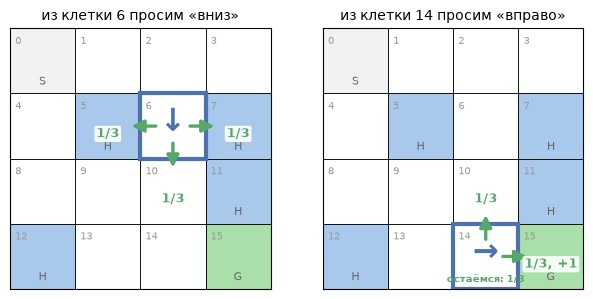

вся среда — это две таблицы: p(s'|s,a) размера (16, 4, 16) и r(s,a) размера (16, 4); r(14, →) = 0.33


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.8))
draw_transitions(lake, s=6, a=1, ax=axes[0])
draw_transitions(lake, s=14, a=2, ax=axes[1])
plt.show()
print(f"вся среда — это две таблицы: p(s'|s,a) размера {P.shape} и r(s,a) размера {R.shape}; r(14, →) = {R[14, 2]:.2f}")

Две таблицы, $16 \times 4 \times 16$ и $16 \times 4$, — и это **вся** среда: любой вопрос о будущем озера можно получить из них, не запуская `env.step` ни разу. Держите это в уме: скоро мы будем ими пользоваться, а потом — спрашивать, как обойтись без них.

### 2.2 Агент, стратегия, траектория

Субъект, который взаимодействует со средой и влияет на неё, называется **агентом**. Агент руководствуется правилом, как выбирать действия в зависимости от состояния; оно называется **стратегией** (policy; часто говорят «политика») и моделируется распределением $\pi(a \mid s)$. Стратегия и есть объект нашего поиска: как и в классическом ML, мы ищем функцию — только теперь функцию «состояние → что делать».

Взаимодействие устроено так. Среда находится в состоянии $s_0$. Агент сэмплирует действие $a_0 \sim \pi(a \mid s_0)$. Среда отвечает: сэмплирует следующее состояние $s_1 \sim p(s' \mid s_0, a_0)$ и выдаёт награду $r_0$. Процесс повторяется: $a_1$, затем $s_2$ и $r_1$, и так далее — до бесконечности или пока среда не перейдёт в **терминальное состояние** (прорубь или цель), после которого взаимодействие прерывается и сбор награды заканчивается. Один заход от начального состояния до терминального — **эпизод**; цепочка случайных величин $s_0, a_0, s_1, a_1, s_2, \ldots$ — **траектория**.

Итак, среда для нас — **управляемая марковская цепь**: на каждом шаге агент выбором $a$ определяет, из какого распределения будет сгенерировано следующее состояние. В этой модели три предположения:

1. **Марковость**: переход в следующее состояние определяется только текущим состоянием и действием, а не всей историей. Это требование к тому, что мы называем состоянием: одна фотография летящего мяча — не состояние, фотография плюс скорость — состояние.
2. **Стационарность**: функция переходов не зависит от времени. Законы мира не меняются от того, сколько шагов прошло.
3. **Полная наблюдаемость**: агент видит состояние целиком. Это единственное по-настоящему нереалистичное допущение: в жизни нам доступны лишь частичные наблюдения. Такая ситуация моделируется частично наблюдаемыми MDP (POMDP), а на практике в наблюдение добавляют историю (DQN в Atari подаёт в сеть четыре последних кадра). Мы дальше ограничиваемся полностью наблюдаемыми средами.

![pomdp](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/observation_vs_state.png)

### 2.3 Чего мы хотим

На каждом шаге агенту приходит награда $r_t$, но состояния и действия — случайные величины. Один и тот же агент из-за случайности внутренней (выбор действия по стратегии) и внешней (функция переходов) может набрать очень разную суммарную награду $\sum_{t \ge 0} r_t$ в зависимости от везения. Поэтому мы хотим набирать много награды **в среднем**.

В среднем по чему? По всей случайности, заложенной в процесс. Каждая стратегия $\pi$ задаёт распределение на траекториях:

$$
p(\tau \mid \pi) = p(s_0)\, \pi(a_0 \mid s_0)\, p(s_1 \mid s_0, a_0)\, \pi(a_1 \mid s_1)\, p(s_2 \mid s_1, a_1) \cdots
$$

Вот по нему и усредняем. Есть ещё одна поправка: в средах, где взаимодействие может продолжаться бесконечно, агент может набирать бесконечную награду, и начинаются парадоксы (получать $+1$ на каждом втором шаге становится так же хорошо, как $+1$ на каждом сотом). Поэтому вводят **дисконтирование**: *тортик сейчас лучше, чем тот же самый тортик завтра*. Награду через $t$ шагов умножаем на $\gamma^t$, где $\gamma < 1$ (у нас $\gamma = 0.95$). Итоговая цель:

$$
\boxed{\;J(\pi) = \mathbb E_{\tau \sim \pi}\Big[\sum_{t \ge 0} \gamma^t r_t\Big] \;\to\; \max_\pi\;}
$$

Сумму под матожиданием мы в лекции 1 называли **return** и обозначали $G$. Посмотрим на неё для одного эпизода озера — и заметим её главное свойство:

![return](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/return_recursion.png)

Return с шага $t$ — это награда за этот шаг плюс дисконтированный return с шага $t+1$: $G_t = r_t + \gamma G_{t+1}$. Тривиальная перегруппировка суммы, но через полчаса из неё вырастет главное уравнение курса.

> **Итог раздела.** RL — это в первую очередь **задача оптимизации** функционала определённого вида. В классическом ML подбор функции потерь — часть инженерной работы; здесь функция награды дана готовой и **определяет** тот функционал, который мы оптимизируем. Что мы будем делать с этим функционалом дальше, зависит только от его структуры, а не от того, озеро перед нами или робот.

## 3. Примеры MDP (📖 дома)

Формализм MDP очень общий: под него попадает почти всё, что можно назвать «интеллектуальной задачей» (с оговоркой, что не всегда очевидно, какая функция награды задаёт ту или иную задачу).

* **Клетчатые миры (GridWorld).** Самые простые MDP рисуют на бумажке: агент стоит в клетке доски и выбирает одно из четырёх направлений. Миры могут по-разному реагировать на «пойти в стену», с некоторой вероятностью сносить агента не туда, содержать предметы в клетках. Пространства состояний и действий конечны, их можно перечислить — такие MDP называют **табличными**. Наше озеро — из этой семьи.

  ![gridworld](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/mdp_gridworld.png)

* **Видеоигры.** Агенту подаётся изображение экрана, и несколько раз в секунду он выбирает, какие кнопки нажать. Пространство состояний — множество всех возможных картинок: формально конечное, но такое, что перечислить или сохранить все варианты нельзя. Действий же по-прежнему немного: это задачи **дискретного управления**.

* **Физические симуляции.** Научить «существо» ходить в физическом движке (locomotion): на каждом шаге агент выбирает несколько вещественных чисел в $[-1, 1]$ — «максимально расслабить» или «максимально напрячь» каждый сустав. Это **непрерывное управление**, оно повсюду в робототехнике.

Концептуально алгоритму RL всё равно, как устроена симуляция и как задана награда: мы строим **общий** метод оптимизации функционала из раздела 2. Разница между примерами — в том, помещается ли таблица «состояние × действие» в память и можно ли перебрать все действия. Это определит, что из сегодняшней лекции работает «как есть», а что потребует нейросетей.

## 4. Окей, и как такое решать?

Выглядит сложновато, но с основной идеей вы уже сталкивались: она называется **динамическим программированием**.

Мы оптимизируем не абы какой функционал, а среднюю дисконтированную сумму наград, и у него есть структура. Вот мы сидим в состоянии $s$ и хотим выбрать действие $a$ как можно лучше. Мы знаем, что после этого получим награду за шаг $r$, среда перекинет нас в состояние $s'$ — и, внимание, дальше нас ждёт **подзадача той же структуры**: в точности та же задача выбора оптимального действия, только из другого состояния. На прошлое мы повлиять уже не можем; стационарность говорит, что законы среды не поменялись; марковость — что история на дальнейшее не влияет. Значит, задача «набрать максимум награды из $s$» тесно связана с задачей «набрать максимум награды из $s'$», каким бы $s'$ ни оказалось.

### 4.1 Оптимальная Q-функция

Чтобы записать это на языке математики, вводят вспомогательные величины — **оценочные функции**. Первая и главная — **оптимальная Q-функция** $Q^*(s, a)$: *сколько максимально награды можно в среднем набрать после того, как в состоянии $s$ выбрано действие $a$*:

$$
Q^*(s, a) = \max_\pi\ \mathbb E_{\tau \sim \pi \mid s_0 = s,\, a_0 = a}\Big[\sum_{t \ge 0} \gamma^t r_t\Big].
$$

Запись $\tau \sim \pi \mid s_0 = s, a_0 = a$ означает: садимся в состояние $s$, делаем действие $a$, а дальше действуем по стратегии $\pi$. Чтобы посчитать $Q^*$ по определению, нужно перебрать **все** стратегии и взять лучшую. Поэтому функция и называется оптимальной: она предполагает, что после первого шага агент будет вести себя идеально.

Определение неконструктивное — перебрать все стратегии мы не можем. Зато у него есть замечательное свойство: **если мы каким-то чудом узнали $Q^*$, мы знаем оптимальную стратегию.** Представьте: вы в состоянии $s$, у вас три действия, и вы знаете, что после первого можно набрать не больше $+3$, после второго — $+10$, после третьего — в среднем $-1$. Причём для каждого числа существует стратегия, которая столько действительно набирает. Как действовать?

![choice](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/q_choice.png)

Интуиция подсказывает выбрать второе действие, и она не обманывает: больше $+10$ отсюда набрать нельзя по определению $Q^*$. Это **принцип оптимальности Беллмана**: выбор действия, на котором достигается максимум $Q^*$, — **жадный** (greedy) по отношению к $Q^*$ — оптимален:

$$
\pi^*(s) = \arg\max_a Q^*(s, a).
$$

Если максимум достигается на нескольких действиях, годится любое. Заметьте: оптимальная стратегия получилась **детерминированной**. Значит, искать случайную стратегию, в общем-то, не обязательно, а вся задача сводится к поиску одной функции $Q^*$.

Проверим на озере. Представим, что кто-то дал нам $Q^*$ (как её вычислить — через десять минут).

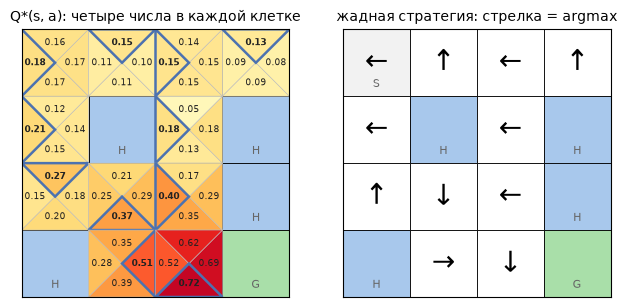

жадная стратегия доходит до цели в 73% эпизодов


In [4]:
pi_star = greedy_policy(Q_star)                                       # в каждой клетке: argmax_a Q*(s, a)

fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.8))
plot_q(Q_star, desc, ax=axes[0], title="Q*(s, a): четыре числа в каждой клетке")
draw_policy(pi_star, desc, ax=axes[1], title="жадная стратегия: стрелка = argmax")
plt.show()
print(f"жадная стратегия доходит до цели в {success_rate(lake, pi_star, np.random.default_rng(0), 2000):.0%} эпизодов")

Посмотрите на стрелки: из стартовой клетки оптимально идти **влево, в стену**, и в клетке 14 — не вправо к цели, а **вниз, в стену**. В обоих случаях шанс продвинуться тот же $1/3$, а вот при неудаче агент остаётся на безопасной клетке вместо того, чтобы рисковать. В лекции 1 мы заметили этот трюк глазами, разглядывая таблицу переходов одной клетки; $Q^*$ содержит его для всех клеток сразу. И это **лучшее, что можно сделать на этом озере**: 73% — потолок, никакой алгоритм не даст больше (Cross-Entropy из домашнего задания лекции 1 до него не дотягивает и скачет от запуска к запуску).

Итак: если знаем $Q^*$ — знаем всё. Осталось понять, как её искать.

## 5. Уравнение оптимальности Беллмана

Тут и пригодится наблюдение про структуру задачи: **$Q^*$ выражается через саму себя**. Начнём с конкретной клетки, потом запишем буквами.

### 5.1 Клетка 14, действие «вправо»

Два взгляда на число $Q^*(14, \rightarrow)$.

*Первый взгляд, по определению:* это максимум того, что можно в среднем набрать, сделав из клетки 14 шаг вправо и дальше играя идеально.

*Второй взгляд, на один шаг вперёд.* После действия среда сэмплирует исход — один из трёх, по $1/3$:
* попали в цель (клетка 15): награда $1$, эпизод окончен, дальше набрать ничего нельзя;
* снесло вверх (клетка 10): награда $0$, а дальше — та же задача из клетки 10, и идеальный агент наберёт там $\max_{a'} Q^*(10, a')$;
* снесло в стену (остались в 14): награда $0$, и дальше идеальный агент наберёт $\max_{a'} Q^*(14, a')$.

Всё, что будет после первого шага, дисконтируется на $\gamma$, а по исходам нужно усреднить — на них мы не влияем. Посчитаем, подставив настоящие числа из $Q^*$ выше.

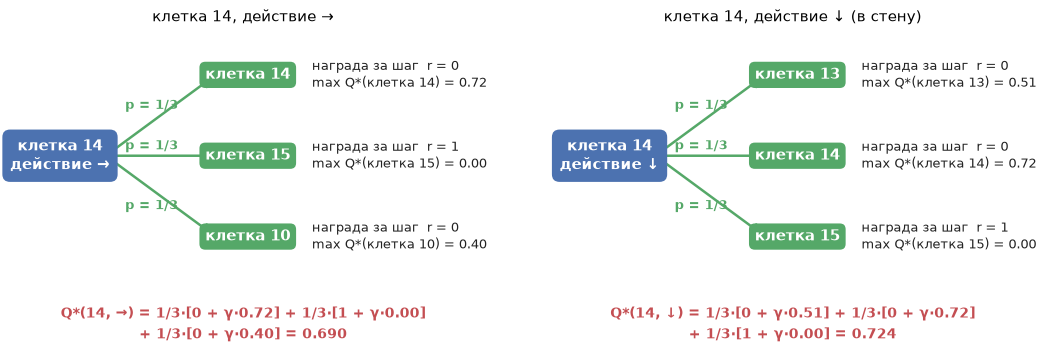

а вот числа из самой таблицы Q*: Q*(14, →) = 0.690,  Q*(14, ↓) = 0.724


In [5]:
V_star = Q_star.max(axis=1)                                            # лучшее, что можно набрать из каждой клетки

def outcomes(s, a):                                                    # исходы среды для пары (s, a): (s', вероятность, награда, max_a' Q*(s', a'))
    return [(s_next, prob, reward, V_star[s_next]) for prob, s_next, reward, _ in lake.unwrapped.P[s][a]]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
draw_backup(14, 2, outcomes(14, 2), GAMMA, ax=axes[0], value_name="max Q*", q_name="Q*", title="клетка 14, действие →")
draw_backup(14, 1, outcomes(14, 1), GAMMA, ax=axes[1], value_name="max Q*", q_name="Q*", title="клетка 14, действие ↓ (в стену)")
plt.show()
print(f"а вот числа из самой таблицы Q*: Q*(14, →) = {Q_star[14, 2]:.3f},  Q*(14, ↓) = {Q_star[14, 1]:.3f}")

Арифметика «на один шаг вперёд» дала ровно те числа, что стоят в таблице $Q^*$. Заодно видно, почему «вниз, в стену» лучше, чем «вправо»: цель в обоих случаях с вероятностью $1/3$, но при неудаче слева остаёмся в клетках 14 и 13 (ценности 0.72 и 0.51), а справа — в 14 и 10 (0.72 и 0.40).

### 5.2 То же буквами

Для произвольной пары $(s, a)$ рассуждение то же самое: получаем награду за шаг, среда сэмплирует $s' \sim p(s' \mid s, a)$ — по этой случайности усредняем, — а дальше идеальный агент выберет то действие $a'$, на котором достигается $\max_{a'} Q^*(s', a')$. Итого — **уравнение оптимальности Беллмана**:

$$
\boxed{\;Q^*(s, a) = \mathbb E_{s' \sim p(s' \mid s, a)}\Big[\, r(s, a, s') + \gamma \max_{a'} Q^*(s', a') \Big]\;}
$$

Для каждой пары $(s, a)$ — своё уравнение, и в каждом справа стоят значения $Q^*$ в других парах. На озере это $16 \times 4 = 64$ уравнения с 64 неизвестными. Система **нелинейная** из-за максимума, но оказывается, что она «хорошая»: у неё **единственное решение**, так что уравнение можно считать вторым, эквивалентным определением $Q^*$ — уже без перебора всех стратегий.

### 5.3 Метод простой итерации

А решать её можно **методом простой итерации**: для уравнения вида $x = f(x)$ берём произвольное приближение и подставляем его в правую часть, снова и снова. Инициализируем любую таблицу $Q_0$ (например, нулями) и повторяем:

$$
Q_{k+1}(s, a) \leftarrow \mathbb E_{s'}\Big[\, r + \gamma \max_{a'} Q_k(s', a') \Big] \quad \text{для всех } (s, a).
$$

В пределе получим истинную $Q^*$, а с ней и оптимальную стратегию. Когда вы раньше встречали динамическое программирование, вы неявно использовали именно эту идею: в задачах на бумажке неизвестные обычно удаётся исключать последовательно, а простая итерация — общая схема, применимая всегда. Проверим: три строки кода.

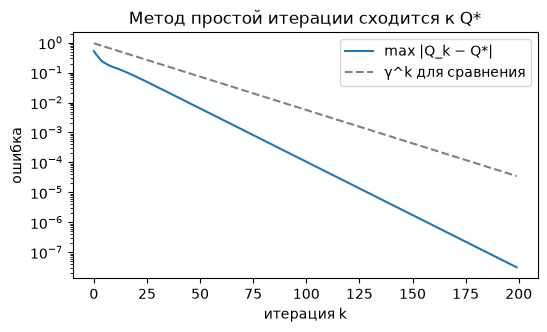

через 200 итераций ошибка 3.1e-08; жадные стратегии по Q и по Q* совпадают: True


In [6]:
Q, errors = np.zeros((n_states, n_actions)), []
for k in range(200):
    Q = R + GAMMA * P @ Q.max(axis=1)                                  # правая часть уравнения оптимальности сразу для всех (s, a)
    errors.append(np.abs(Q - Q_star).max())

plt.figure(figsize=(6, 3.2))
plt.semilogy(errors, label="max |Q_k − Q*|"); plt.semilogy(GAMMA ** np.arange(1, 201), "--", color="grey", label="γ^k для сравнения")
plt.xlabel("итерация k"); plt.ylabel("ошибка"); plt.legend(); plt.title("Метод простой итерации сходится к Q*")
plt.show()
print(f"через 200 итераций ошибка {errors[-1]:.1e}; жадные стратегии по Q и по Q* совпадают: {np.array_equal(Q.argmax(1), Q_star.argmax(1))}")

Ошибка убывает геометрически, не медленнее $\gamma^k$: каждая подстановка в правую часть сжимает расстояние до ответа. Так работает динамическое программирование, и это же свойство — *сжимаемость* — на неделе 3 мы докажем в одну строку и увидим, что оно объясняет сходимость почти всех методов курса.

Для нас сейчас принципиально другое: **если есть какое-то приближение $Q^*$, то вычисление правой части уравнения даёт приближение лучше.** Это единственное, что нужно запомнить из раздела, чтобы понять всё остальное.

> **Факт.** Ричард Беллман сформулировал принцип оптимальности и это уравнение в 1950-х в RAND Corporation, и он же придумал термин «проклятие размерности»: число состояний растёт экспоненциально с числом переменных, описывающих ситуацию. Поэтому таблица $64$ уравнений — роскошь озера; для шахмат или робота никто её не выпишет. Что тогда — раздел 7.

<details>
<summary><b>Самопроверка.</b> Чему равно $Q^*(s, a)$ для терминальной клетки $s$ (прорубь или цель) и почему?</summary>

Нулю: из терминального состояния взаимодействие не продолжается, награды больше не будет. В таблице это удобно записать как «из терминальной клетки среда с вероятностью 1 остаётся в ней с наградой 0» — тогда уравнение даёт $Q^* = 0 + \gamma \cdot 0 = 0$ автоматически. Именно поэтому в арифметике для клетки 14 у исхода «цель» стояло $\max Q^*(15, \cdot) = 0$, а награда $1$ учитывалась в ценности **соседней** клетки.

</details>

## 6. А если стратегия задана? Оценочные функции $V^\pi$ и $Q^\pi$

До сих пор мы говорили только об **оптимальном** поведении. Но часто нужно ответить на более скромный вопрос: *насколько хороша вот эта конкретная стратегия* — случайная, ручная, выученная Cross-Entropy? Для этого те же оценочные функции определяют для **заданной** стратегии $\pi$:

$$
V^\pi(s) = \mathbb E_{\tau \sim \pi \mid s_0 = s}\Big[\sum_{t \ge 0} \gamma^t r_t\Big], \qquad
Q^\pi(s, a) = \mathbb E_{\tau \sim \pi \mid s_0 = s,\, a_0 = a}\Big[\sum_{t \ge 0} \gamma^t r_t\Big].
$$

$V^\pi(s)$ — **ценность состояния**: сколько в среднем наберём, стартовав из $s$ и дальше играя по $\pi$. Это ровно та тепловая карта, которую мы рисовали в лекции 1, — теперь у неё есть определение. $Q^\pi(s, a)$ — **ценность действия**: то же, но первое действие зафиксировано. Оба числа зависят от стратегии: клетка рядом с целью ценна для умного агента и почти бесполезна для того, кто дальше блуждает наугад. Оптимальные функции — их лучший случай: $Q^*(s, a) = \max_\pi Q^\pi(s, a)$, а $V^*(s) = \max_a Q^*(s, a)$ — то самое «лучшее из клетки», которое мы обозначали `V_star` в демо выше.

### 6.1 Как связаны $V^\pi$ и $Q^\pi$

Две связи, обе — прямо из определений.

**Ценность состояния — среднее ценностей действий по стратегии.** В состоянии $s$ агент выберет действие $a$ с вероятностью $\pi(a \mid s)$, и дальше его ждёт в среднем $Q^\pi(s, a)$:

$$
V^\pi(s) = \sum_a \pi(a \mid s)\, Q^\pi(s, a).
$$

**Ценность действия — награда за шаг плюс дисконтированная ценность того, куда попадём.** Это та же картинка «на один шаг вперёд», что в разделе 5, только вместо $\max_{a'} Q^*(s', a')$ в листьях стоит $V^\pi(s')$ — ведь дальше агент играет не идеально, а по $\pi$:

$$
Q^\pi(s, a) = \mathbb E_{s' \sim p(s' \mid s, a)}\Big[\, r(s, a, s') + \gamma\, V^\pi(s') \Big].
$$

Подставим первую связь во вторую — получим **уравнение Беллмана для заданной стратегии**:

$$
\boxed{\;V^\pi(s) = \sum_a \pi(a \mid s)\, \mathbb E_{s'}\Big[\, r(s, a, s') + \gamma\, V^\pi(s') \Big]\;}
$$

### 6.2 Два уравнения — два вопроса

| | Уравнение оптимальности (раздел 5) | Уравнение для заданной стратегии |
|---|---|---|
| на какой вопрос отвечает | какая стратегия **лучшая** и сколько она набирает | сколько набирает **вот эта** стратегия, любая, хоть случайная |
| неизвестные | $Q^*(s, a)$ | $V^\pi(s)$ (или $Q^\pi(s, a)$) |
| что стоит после $\gamma$ | $\max_{a'} Q^*(s', a')$ — агент выберет лучшее | $V^\pi(s') = \sum_{a'} \pi(a' \mid s') Q^\pi(s', a')$ — агент выберет по $\pi$ |
| вид системы | нелинейная (из-за $\max$) — только итерации | **линейная** — решается одной строкой |
| зачем | найти оптимальную стратегию | оценить стратегию, сравнить две стратегии, а потом улучшить: жадный выбор по $Q^\pi$ не хуже $\pi$ (неделя 3, policy iteration) |

Отличие ровно одно: усреднение по стратегии $\sum_a \pi(a \mid s)$ вместо $\max_a$. И раз для заданной стратегии уравнение линейно, ценность **любой** стратегии в табличном MDP можно посчитать точно — без единого эпизода. Сравним с Монте-Карло из лекции 1 на равномерной стратегии.

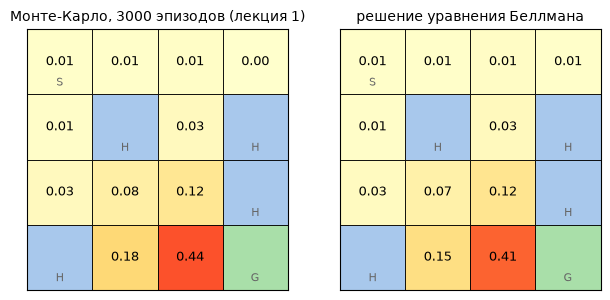

наибольшее расхождение: 0.027


In [7]:
uniform = np.ones((n_states, n_actions)) / n_actions                   # кубик в каждой клетке
P_pi = np.einsum("sa,sat->st", uniform, P)                            # цепь при фиксированной стратегии: P_π[s, s'] = Σ_a π(a|s) p(s'|s, a)
r_pi = (uniform * R).sum(axis=1)                                      # средняя награда за шаг из s
V_exact = np.linalg.solve(np.eye(n_states) - GAMMA * P_pi, r_pi)      # уравнение Беллмана V = r_π + γ P_π V как линейная система

rng = np.random.default_rng(1)
V_mc = estimate_values([run_session(lake, uniform, rng) for _ in range(3000)], n_states)

fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.6))
plot_values(V_mc, desc, ax=axes[0], vmax=0.6, title="Монте-Карло, 3000 эпизодов (лекция 1)")
plot_values(V_exact, desc, ax=axes[1], vmax=0.6, title="решение уравнения Беллмана")
plt.show()
print(f"наибольшее расхождение: {np.nanmax(np.abs(V_mc - V_exact)):.3f}")

Одна строка `np.linalg.solve` дала то, на что Монте-Карло потратил 3000 эпизодов, — и дала точно: правая карта не шумит. Заметьте, насколько случайная стратегия хуже оптимальной: из старта она набирает 0.01 против $V^*(\text{старт}) = 0.18$.

<details>
<summary><b>Самопроверка.</b> Когда $V^\pi(s) = Q^\pi(s, a)$? И почему $V^\pi(s) \le V^*(s)$ для любой стратегии?</summary>

Первое — когда стратегия в $s$ детерминированная и выбирает именно $a$: среднее по действиям состоит из одного слагаемого. Второе — по определению $V^*$ как максимума по всем стратегиям: лучше оптимальной не бывает нигде, ни в одной клетке.

</details>

## 7. А где же метод проб и ошибок?

Решать уравнение оптимальности простой итерацией и получать $Q^*$ можно только при двух существенных условиях.

**Во-первых**, нужно хранить текущее приближение $Q_k(s, a)$ в памяти. Это возможно, если состояний и действий немного: в MDP на 10 состояний и 5 действий $Q$ — табличка $10 \times 5$. Но если состояние — картинка с экрана видеоигры, таблицу не сохранить. Пока считаем, что таблица помещается; на неделе 5 мы снимем это ограничение, заменив таблицу нейросетью.

**Во-вторых**, нужно уметь считать правую часть уравнения — матожидание по $p(s' \mid s, a)$. Мало того, что в сложных средах его не взять, так ещё и функцию переходов мы обычно **не знаем**. Катаясь на велосипеде, можете ли вы по положению всех атомов во вселенной сказать, с какими вероятностями в каком состоянии мир окажется через мгновение? Хорошо бы обойтись без этого, даже не пытаясь выучить функцию переходов.

### 7.1 Переходы и Беллмановский таргет

Что нам доступно? Взять какую-нибудь стратегию (важно: мы должны сами её выбрать) и **попробовать** — повзаимодействовать со средой. Можно сыграть целую траекторию, а можно сделать всего один шаг: были в $s$, сделали $a$, узнали награду $r$ и, главное, куда среда нас перевела — $s'$. Этот $s'$ — **сэмпл** из $p(s' \mid s, a)$. Четвёрка $(s, a, r, s')$ называется **переходом** (transition) — это наша единица опыта.

Можно ли, имея только переходы, пользоваться схемой простой итерации? Заменим правую часть, которую посчитать нельзя,

$$
\mathbb E_{s'}\big[\, r + \gamma \max_{a'} Q_k(s', a') \big],
$$

на её оценку по одному сэмплу:

$$
y = r + \gamma \max_{a'} Q_k(s', a'), \qquad s' \text{ — из перехода}.
$$

В среднем такая замена верна. Эта величина называется **Беллмановским таргетом** — «целевой переменной», и почему так, увидим на неделе 5.

Но жёстко заменять $Q_k(s, a)$ на таргет по одному переходу нельзя. Пусть после $(s, a)$ награда $0$, а среда с равной вероятностью кидает нас в $s'$ с $\max_{a'} Q_k = +1$ или в $s'$ с $\max_{a'} Q_k = -1$. Простая итерация велит записать $0.5 \gamma \cdot (+1) + 0.5 \gamma \cdot (-1) = 0$, но мы увидим лишь **один** исход, и таргет будет $+\gamma$ или $-\gamma$ — нам могло повезти или не повезти. Поступим, как учат среднее по выборке: не заменяем, а **смешиваем** текущее приближение с новым сэмплом:

$$
\boxed{\;Q(s, a) \leftarrow (1 - \alpha)\, Q(s, a) + \alpha\, \big[\, r + \gamma \max_{a'} Q(s', a') \big]\;}
\qquad\Longleftrightarrow\qquad
Q(s, a) \leftarrow Q(s, a) + \alpha\, \underbrace{\big[\, r + \gamma \max_{a'} Q(s', a') - Q(s, a) \big]}_{\text{таргет} - \text{текущая оценка}}.
$$

Это экспоненциальное сглаживание старой оценки и свежего таргета; $\alpha$ определяет, насколько сильно мы верим последним сэмплам, и по смыслу это **learning rate**. В среднем по случайности $s'$ мы сдвигаемся в сторону настоящей правой части уравнения — получается «зашумлённый» метод простой итерации, который обновляет по одной ячейке таблицы за переход и не требует знать $p$. Очень похоже на стохастический градиентный спуск, и гарантии сходимости выглядят так же: если каждую пару $(s, a)$ обновлять бесконечно много раз, а $\alpha$ убывает как learning rate в SGD, процесс сходится к $Q^*$.

### 7.2 Пример: Колобок и лотерея

Колобок Колабулька любит играть в лотереи. В состоянии $s$ «у киоска» он выполнил действие «купить билет» и полагает, что после этого сможет набрать $Q^*(s, \text{купить}) = +100$. Билет стоит 10, так что за шаг $r = -10$, а среда возвращает Колобка в то же состояние $s' = s$, где снова можно купить билет или уйти домой ($Q^*(s, \text{не покупать}) = 0$). Возьмём для простоты $\gamma = 1$.

![lottery](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/lottery_mdp.png)

Беллмановский таргет: $r + \gamma \max_{a'} Q^*(s', a') = -10 + \max(100, 0) = 90$. Да, $s'$ — случайная величина, Колобку могло повезти или нет, но формула говорит сдвинуть оценку в сторону 90. При $\alpha = 0.5$ оценка $+100$ опускается до $95$. Всё ещё $95 > 0$, покупать кажется выгоднее, Колобок покупает снова, снова теряет 10 и снова попадает в $s$: таргет $85$, оценка $90$. Если так и не будет везти, оценка будет падать на 5 за шаг, пока не свалится до нуля — и там станет выгоднее не покупать. Но если на очередном шаге среда переведёт Колобка в состояние «выигрыш» с наградой $+1000$, таргет будет огромным, и оценка резко вырастет.

Куда всё это сойдётся? Пусть с вероятностью $p$ билет проигрышный и мы снова у киоска, а с вероятностью $1-p$ выигрышный, приз $+1000$, конец эпизода. Уравнение оптимальности для действия «купить»:

$$
Q^*(s, \text{купить}) = -10 + p \cdot \max\big(Q^*(s, \text{купить}),\, 0\big) + (1 - p) \cdot 1000.
$$

При $p = 0.99$ решение — $Q^* = 0$: билет стоит 10, а приносит $1000$ с вероятностью $0.01$; «купить» и «не купить» равноценны. При $p > 0.99$ покупать невыгодно, при $p < 0.99$ — выгодно, пока не выиграешь. Несмотря на то, что в таргете стоит собственная текущая оценка и один сэмпл $s'$ вместо честного усреднения, обновления постепенно сойдутся к этому решению — а истинное $p$ Колобку знать не нужно: оно влияет только на то, какой $s'$ попадётся в очередном таргете.

не везёт пять раз, потом выигрыш (α = 0.5): [100.   95.   90.   85.   80.   75.  532.5]


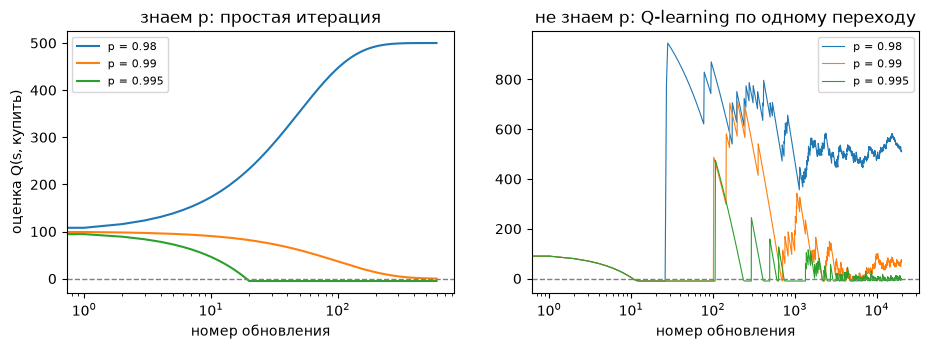

In [8]:
def lottery_updates(outcomes, alpha, q0=100.0, gamma=1.0):
    """Обновления Q(s, купить) по переходам: outcomes — список True (выигрыш) / False (снова у киоска), alpha — число или функция от шага."""
    q, history = q0, [q0]
    for k, win in enumerate(outcomes):
        target = -10 + gamma * (1000 if win else max(q, 0))            # Беллмановский таргет: награда за шаг + лучшее, что можно сделать дальше
        a = alpha(k) if callable(alpha) else alpha
        q = (1 - a) * q + a * target; history.append(q)
    return np.array(history)

print("не везёт пять раз, потом выигрыш (α = 0.5):", np.round(lottery_updates([False] * 5 + [True], alpha=0.5), 1))

rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for p in [0.98, 0.99, 0.995]:
    exact = [100.0]                                                    # знаем p: метод простой итерации из раздела 5
    for _ in range(600):
        exact.append(-10 + p * max(exact[-1], 0) + (1 - p) * 1000)
    axes[0].plot(exact, label=f"p = {p}")
    samples = lottery_updates(rng.random(20_000) > p, alpha=lambda k: 1 / (1 + k / 100))   # не знаем p: только переходы, α убывает
    axes[1].plot(samples, lw=0.8, label=f"p = {p}")
axes[0].set_title("знаем p: простая итерация"); axes[1].set_title("не знаем p: Q-learning по одному переходу")
for ax in axes:
    ax.axhline(0, color="grey", ls="--", lw=1); ax.set_xscale("log"); ax.set_xlabel("номер обновления"); ax.legend(fontsize=8)
axes[0].set_ylabel("оценка Q(s, купить)")
plt.show()

Первые шесть чисел — ровно история Колобка: $100 \to 95 \to 90 \to 85 \to 80 \to 75$, а после выигрыша — скачок к $532$. Справа видно, как ведёт себя обучение по переходам: при $p = 0.98$ оценка шумно, но сходится к $500$ — решению уравнения, при $p = 0.995$ — к $-5$, при $p = 0.99$ — колеблется около нуля. Медленно и с шумом, потому что редкий выигрыш $+1000$ каждый раз «встряхивает» оценку, — но к тому же ответу, что и точная итерация слева.

### 7.3 Как собирать данные: exploration и exploitation

Остался один вопрос: **как** взаимодействовать со средой, чтобы каждую пару $(s, a)$ обновлять бесконечно много раз? Если хочется набирать награду уже сейчас, естественно действовать жадно по текущей оценке $Q_k$ — это **exploitation**. Но жадная стратегия детерминирована, и многие пары $(s, a)$ она не выберет никогда — а значит, никогда их и не обновит. Так алгоритм застревает: научившись, что велосипед приносит $-5$ за каждое дерево, он решит вовсе не садиться на велосипед и получать $0$ — просто потому, что действия, ведущие к положительной награде, ни разу не пробовал.

Значит, нужно **исследовать** (exploration): взаимодействовать стратегией, у которой $\pi(a \mid s) > 0$ для всех пар. Случайная стратегия годится в теории, но до интересных областей она добирается с экспоненциально малой вероятностью. Разумнее совместить: с вероятностью $\varepsilon$ выбирать случайное действие, с вероятностью $1 - \varepsilon$ — жадное. Это **$\varepsilon$-жадная стратегия**, самый простой способ разрешить дилемму (в лекции 1 она называлась «исследование и использование»).

Соберём всё вместе — это табличный алгоритм **Q-learning**:

1. Инициализировать таблицу $Q(s, a)$ произвольно (например, нулями).
2. Пронаблюдать $s_0$.
3. Для $k = 0, 1, 2, \ldots$:
   * с вероятностью $\varepsilon$ выбрать $a_k$ случайно, иначе жадно: $a_k = \arg\max_a Q(s_k, a)$;
   * отправить $a_k$ в среду, получить $r_k$ и $s_{k+1}$;
   * обновить одну ячейку: $Q(s_k, a_k) \leftarrow Q(s_k, a_k) + \alpha\,[\, r_k + \gamma \max_{a'} Q(s_{k+1}, a') - Q(s_k, a_k)\,]$.

⏱ **Если есть время.** Запустим его на озере: агент не видит ни $p$, ни $r$ — только переходы.

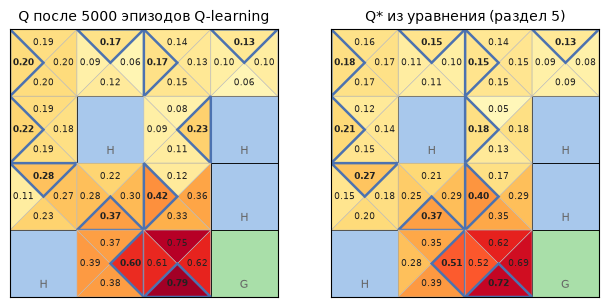

наибольшее расхождение с Q*: 0.13;  жадная стратегия по выученной Q доходит в 72% эпизодов


In [9]:
rng, alpha, eps = np.random.default_rng(0), 0.1, 0.3
Q = np.zeros((n_states, n_actions))
for episode in range(5000):
    s, done = lake.reset(seed=int(rng.integers(1_000_000)))[0], False
    while not done:
        a = int(rng.integers(n_actions)) if rng.random() < eps else int(Q[s].argmax())   # ε-жадный выбор
        s_next, r, terminated, truncated, _ = lake.step(a)
        Q[s, a] += alpha * (r + GAMMA * Q[s_next].max() - Q[s, a])                          # сдвиг к Беллмановскому таргету
        s, done = s_next, terminated or truncated

fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.8))
plot_q(Q, desc, ax=axes[0], title="Q после 5000 эпизодов Q-learning", vmax=Q_star.max())
plot_q(Q_star, desc, ax=axes[1], title="Q* из уравнения (раздел 5)", vmax=Q_star.max())
plt.show()
print(f"наибольшее расхождение с Q*: {np.abs(Q - Q_star).max():.2f};  "
      f"жадная стратегия по выученной Q доходит в {success_rate(lake, greedy_policy(Q), np.random.default_rng(1), 2000):.0%} эпизодов")

Таблица, выученная по переходам, почти совпала с решением уравнения, а жадная стратегия по ней доходит до цели практически так же часто, как оптимальная. Агент ни разу не заглянул в $p(s' \mid s, a)$ — он **пробовал и ошибался**, и уравнение Беллмана превратило пробы в знание. На неделе 3 мы разберём Q-learning и его родственников (SARSA, TD-обучение) подробно.

## 8. Что дальше и итоги

### Чему мы научились по сравнению с лекцией 1

В лекции 1 хорошую стратегию приходилось **искать**: играть тысячи эпизодов и отбирать удачные, а информация из отдельных шагов пропадала. Сегодня мы увидели, что у задачи есть структура — «из $s'$ нас ждёт та же задача», — и из неё вырастает уравнение, которое **вычисляет** оптимальную стратегию: если модель среды известна — простой итерацией, если нет — по одному переходу за раз (Q-learning). Cross-Entropy этой структуры не видел; всё, что будет дальше в курсе, — способы решать уравнение Беллмана, когда таблица $Q$ не помещается в память или переходов мало.

![family](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/bellman_family.png)

### Итоги

1. **Задача RL — оптимизация функционала** $J(\pi) = \mathbb E_{\tau \sim \pi} \sum_t \gamma^t r_t$ на MDP $(\mathcal S, \mathcal A, p, r)$. Награда дана готовой и определяет, что мы оптимизируем; дисконт $\gamma$ — «тортик сейчас лучше, чем завтра».
2. **Оптимальная Q-функция $Q^*(s, a)$** — сколько максимально можно набрать после $(s, a)$. Если её знать, оптимальная стратегия — жадная: $\pi^*(s) = \arg\max_a Q^*(s, a)$ (принцип оптимальности Беллмана), и она детерминирована.
3. **Уравнение оптимальности Беллмана** $Q^*(s, a) = \mathbb E_{s'}[\, r + \gamma \max_{a'} Q^*(s', a')\,]$ выражает $Q^*$ через саму себя; у него единственное решение, и его находит **метод простой итерации**: подстановка приближения в правую часть даёт приближение лучше.
4. **Для заданной стратегии** те же функции $V^\pi$, $Q^\pi$ связаны линейным уравнением Беллмана (вместо $\max_a$ — усреднение по $\pi$): им оценивают и сравнивают стратегии, а жадное улучшение по $Q^\pi$ — путь к policy iteration.
5. **Q-learning**: если модель среды неизвестна, матожидание в уравнении заменяют одним переходом $(s, a, r, s')$ — Беллмановским таргетом — и сдвигают оценку к нему с шагом $\alpha$; данные собирают $\varepsilon$-жадно. Это первый алгоритм курса, который учится **с каждого шага**.

Словарь, который нужно унести с собой: **MDP, функция переходов $p(s' \mid s, a)$, стратегия, траектория, эпизод, терминальное состояние, дисконтирование, return, оценочная функция, оптимальная Q-функция $Q^*$, принцип оптимальности Беллмана, жадная стратегия, уравнение оптимальности Беллмана, метод простой итерации, $V^\pi$ и $Q^\pi$, уравнение Беллмана для заданной стратегии, переход $(s, a, r, s')$, Беллмановский таргет, Q-learning, exploration / exploitation, $\varepsilon$-жадная стратегия**.

## Литература

* [Учебник по машинному обучению ШАД, глава «Обучение с подкреплением»](https://education.yandex.ru/handbook/ml/article/obuchenie-s-podkrepleniem) — первоисточник сегодняшнего изложения: постановка задачи, $Q^*$, Q-learning, дальше DQN и policy gradient. Прочитать целиком до недели 5.
* R. Sutton, A. Barto. *Reinforcement Learning: An Introduction*, 2nd ed. — [бесплатный PDF](http://incompleteideas.net/book/the-book-2nd.html). Глава 3 — MDP и уравнения Беллмана (в порядке «сначала $V^\pi$, потом $V^*$»), глава 4 — динамическое программирование, раздел 6.5 — Q-learning.
* D. Silver. [UCL Course on RL](https://www.davidsilver.uk/teaching/), лекции 2 «Markov Decision Processes» и 3 «Planning by Dynamic Programming».
* [OpenAI Spinning Up: Key Concepts in RL](https://spinningup.openai.com/en/latest/spinningup/rl_intro.html) — краткая сводка обозначений.

## На семинаре и дома

* **Семинар** (`../seminar/seminar.ipynb`): пишем свою среду GridWorld, достаём из неё таблицы $p$ и $r$, считаем ценность стратегии тремя способами (Монте-Карло, линейная система, итерации), делаем шаг жадного улучшения, решаем уравнение оптимальности простой итерацией на скользком поле и сравниваем с Cross-Entropy; в конце — Q-learning на своём поле.
* **ДЗ** (`../homework/homework.ipynb`): среда «управление запасами» как `gym.Env`, её точная модель из распределения спроса, ценность ручной стратегии точно и по Монте-Карло, оптимальная стратегия заказов из уравнения оптимальности; теория — вывод уравнений Беллмана, цепочка из трёх состояний руками и лотерея Колобка.
* **Неделя 3**: динамическое программирование (policy iteration, value iteration), Monte-Carlo и TD-обучение, SARSA и Q-learning подробно, и почему всё это сходится (сжимающие отображения).